In [4]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu



#### Load dataset

In [13]:
csv_file = "black_oil_final_dataset.csv"

df = pd.read_csv(csv_file)
print(df.shape)
df.head()


(55000, 49)


,sim_id,Nx,Ny,Lx,Ly,h,total_years,dt_days,rw,skin,...,final_cum_water_inj_m3,final_recovery_factor,final_p_min_MPa,final_p_max_MPa,final_p_mean_MPa,final_Sw_min,final_Sw_max,final_Sw_mean,final_Sw_producer,OOIP_surface_m3
0,0,15,15,500.0,500.0,20.0,20.0,10.0,0.1,0.0,...,3.145828e+05,0.324238,17.991275,28.555147,25.514558,0.329588,0.747258,0.462766,0.381910,561445.772763
1,1,15,15,500.0,500.0,20.0,20.0,10.0,0.1,0.0,...,5.516713e+05,0.532796,16.025292,23.338072,20.796022,0.343523,0.786663,0.560538,0.463907,776170.078117
2,2,15,15,500.0,500.0,20.0,20.0,10.0,0.1,0.0,...,5.794511e+05,0.464993,13.909596,25.279079,21.181899,0.408326,0.767124,0.556214,0.479929,725726.585541
3,3,15,15,500.0,500.0,20.0,20.0,10.0,0.1,0.0,...,7.267986e+05,0.546319,16.647350,27.642617,23.936056,0.454174,0.765581,0.576969,0.516510,641998.277787
4,4,15,15,500.0,500.0,20.0,20.0,10.0,0.1,0.0,...,1.270855e+06,0.910734,17.267873,24.512900,21.515695,0.626931,0.798993,0.726553,0.683905,624808.888685


In [14]:
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
print('cleaned:', df.shape)


cleaned: (55000, 49)



#### X/Y df's

In [15]:

feature_cols = [
    "Lx","Ly","h",
    'phi','k_mD','p_init_MPa','Sw_init',
    'p_inj_bhp_MPa','p_prod_bhp_MPa',
    'p_ref_MPa','Bw_ref','Bo_ref','cw_1_per_Pa','co_1_per_Pa',
    'mu_w_cP','mu_o_cP','rho_w_sc','rho_o_sc',
    'Swc','Sor','krw0','kro0','nw_exp','no_exp',
    'OOIP_surface_m3',
]

target_cols = [
    'final_cum_oil_prod_m3',
    'final_cum_water_prod_m3',
    'final_cum_water_inj_m3',
    'final_recovery_factor'
]
full_cols = feature_cols + target_cols

X = df[feature_cols].astype(np.float32).values
Y = df[target_cols].astype(np.float32).values

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X).astype(np.float32)
Y_scaled = y_scaler.fit_transform(Y).astype(np.float32)

print('X:', X_scaled.shape, 'Y:', Y_scaled.shape)


X: (55000, 25) Y: (55000, 4)



#### dataset class

In [16]:

@dataclass
class GridConfig:
    model_Nx: int = 32
    model_Ny: int = 32

grid_cfg = GridConfig(model_Nx=32, model_Ny=32)


class BlackOilScalarDataset(Dataset):
    def __init__(self, df, X_scaled, Y_scaled, feature_cols, target_cols, grid_cfg):
        self.df = df.reset_index(drop=True)
        self.X_scaled = torch.tensor(X_scaled, dtype=torch.float32)
        self.Y_scaled = torch.tensor(Y_scaled, dtype=torch.float32)
        self.feature_cols = list(feature_cols)
        self.target_cols = list(target_cols)
        self.grid_cfg = grid_cfg

        yy, xx = torch.meshgrid(
            torch.linspace(0, 1, grid_cfg.model_Ny),
            torch.linspace(0, 1, grid_cfg.model_Nx),
            indexing='ij',
        )
        self.xx = xx.float()
        self.yy = yy.float()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        xvec = self.X_scaled[idx]
        yvec = self.Y_scaled[idx]

        H, W = self.grid_cfg.model_Ny, self.grid_cfg.model_Nx
        param_maps = xvec[:, None, None].expand(-1, H, W)
        inp = torch.cat([
            self.xx[None, :, :],
            self.yy[None, :, :],
            param_maps
        ], dim=0)

        raw = {c: float(self.df.loc[idx, c]) for c in self.df.columns if c in full_cols}
        return inp, xvec, yvec, raw


dataset = BlackOilScalarDataset(df, X_scaled, Y_scaled, feature_cols, target_cols, grid_cfg)

n_train = int(0.8 * len(dataset))
n_val = len(dataset) - n_train

generator = torch.Generator()#.manual_seed(42)
train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=generator)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

sample = dataset[0]
sample[0].shape, sample[1].shape, sample[2].shape


(torch.Size([27, 32, 32]), torch.Size([25]), torch.Size([4]))

#### U-Net

In [17]:

class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1),
            nn.GroupNorm(8 if c_out >= 8 else 1, c_out),
            nn.SiLU(),
            nn.Conv2d(c_out, c_out, 3, padding=1),
            nn.GroupNorm(8 if c_out >= 8 else 1, c_out),
            nn.SiLU(),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels, n_scalar_targets, base=48):
        super().__init__()

        self.enc1 = ConvBlock(in_channels, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = ConvBlock(base * 8, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = ConvBlock(base * 4, base * 2)

        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = ConvBlock(base * 2, base)

        self.field_head = nn.Conv2d(base, 2, 1)  # 0 - p 1 - Sw

        self.scalar_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base * 8, base * 4),
            nn.SiLU(),
            nn.Linear(base * 4, n_scalar_targets),
        )

    def forward(self, x):
        e1 = self.enc1(x)                  # 32x32
        e2 = self.enc2(self.pool(e1))      # 16x16
        e3 = self.enc3(self.pool(e2))      # 8x8
        b = self.bottleneck(self.pool(e3)) # 4x4

        u3 = self.up3(b)
        d3 = self.dec3(torch.cat([u3, e3], dim=1))
        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        fields_raw = self.field_head(d1)
        p = fields_raw[:, 0:1]
        Sw = torch.sigmoid(fields_raw[:, 1:2])

        scalar_scaled = self.scalar_head(b)

        return p, Sw, scalar_scaled

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_channels = 2 + len(feature_cols)
model = UNet(in_channels=in_channels, n_scalar_targets=len(target_cols), base=32).to(device)

sum(p.numel() for p in model.parameters())


1968774

#### differentiable postprocessing

In [18]:

target_index = {c: i for i, c in enumerate(target_cols)}
feature_index = {c: i for i, c in enumerate(feature_cols)}

def unscale_y(y_scaled_t):
    mean = torch.tensor(y_scaler.mean_, dtype=torch.float32, device=y_scaled_t.device)
    scale = torch.tensor(y_scaler.scale_, dtype=torch.float32, device=y_scaled_t.device)
    return y_scaled_t * scale + mean

def unscale_x(x_scaled_t):
    mean = torch.tensor(x_scaler.mean_, dtype=torch.float32, device=x_scaled_t.device)
    scale = torch.tensor(x_scaler.scale_, dtype=torch.float32, device=x_scaled_t.device)
    return x_scaled_t * scale + mean

def recovery_factor_from_fields(p_MPa, Sw, x_raw):
    B, _, H, W = Sw.shape

    phi = x_raw[:, feature_index["phi"]]
    Lx = x_raw[:, feature_index["Lx"]]
    Ly = x_raw[:, feature_index["Ly"]]
    h = x_raw[:, feature_index["h"]]
    Bo_ref = x_raw[:, feature_index["Bo_ref"]]
    co = x_raw[:, feature_index["co_1_per_Pa"]]
    p_ref_MPa = x_raw[:, feature_index["p_ref_MPa"]]
    OOIP = x_raw[:, feature_index["OOIP_surface_m3"]].clamp_min(1e-6)

    p_Pa = p_MPa[:, 0] * 1e6
    p_ref_Pa = p_ref_MPa[:, None, None] * 1e6
    Bo = Bo_ref[:, None, None] / (1.0 + co[:, None, None] * (p_Pa - p_ref_Pa))
    Bo = Bo.clamp_min(0.1)

    cell_volume = (Lx * Ly * h / (H * W))[:, None, None]
    OIP_surface = torch.sum(phi[:, None, None] * cell_volume * (1.0 - Sw[:, 0]) / Bo, dim=(1,2))
    RF = (OOIP - OIP_surface) / OOIP
    return RF.clamp(-1.0, 2.0)

def bhp_boundary_loss(p_MPa, x_raw):
    p_inj = x_raw[:, feature_index["p_inj_bhp_MPa"]]
    p_prod = x_raw[:, feature_index["p_prod_bhp_MPa"]]

    p_inj_pred = p_MPa[:, 0, 0, 0]
    p_prod_pred = p_MPa[:, 0, -1, -1]

    return F.mse_loss(p_inj_pred, p_inj) + F.mse_loss(p_prod_pred, p_prod)

def smoothness_loss(field):
    dx = field[:, :, :, 1:] - field[:, :, :, :-1]
    dy = field[:, :, 1:, :] - field[:, :, :-1, :]
    return (dx ** 2).mean() + (dy ** 2).mean()

def rf_consistency_loss(p_MPa, Sw, y_true_scaled, x_raw):
    y_true = unscale_y(y_true_scaled)
    RF_pred = recovery_factor_from_fields(p_MPa, Sw, x_raw)
    RF_true = y_true[:, target_index["final_recovery_factor"]]
    return F.mse_loss(RF_pred, RF_true), RF_pred



#### Training part

In [ ]:

def train_one_epoch(model, loader, optimizer, lambdas):
    model.train()
    total = 0.0

    for inp, x_scaled, y_scaled, _ in tqdm(loader, leave=False):
        inp = inp.to(device)
        x_scaled = x_scaled.to(device)
        y_scaled = y_scaled.to(device)
        x_raw = unscale_x(x_scaled)

        p, Sw, scalar_scaled = model(inp)

        # loss_scalar = F.mse_loss(scalar_scaled, y_scaled)
        # loss_field_stats = scalar_field_stat_loss(p, Sw, y_scaled, x_raw)
        # loss_bhp = bhp_boundary_loss(p, x_raw)
        # loss_smooth = smoothness_loss(p) + smoothness_loss(Sw)

        # loss = (
        #     lambdas['scalar'] * loss_scalar
        #     + lambdas['field_stats'] * loss_field_stats
        #     + lambdas['bhp'] * loss_bhp
        #     + lambdas['smooth'] * loss_smooth
        # )
        loss_scalar = F.mse_loss(scalar_scaled, y_scaled)
        loss_rf_consistency, RF_pred = rf_consistency_loss(p, Sw, y_scaled, x_raw)
        loss_bhp = bhp_boundary_loss(p, x_raw)
        loss_smooth = smoothness_loss(p) + smoothness_loss(Sw)

        loss = (
            lambdas["scalar"] * loss_scalar
            + lambdas["rf_consistency"] * loss_rf_consistency
            + lambdas["bhp"] * loss_bhp
            + lambdas["smooth"] * loss_smooth
        )


        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * inp.size(0)

    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, lambdas):
    model.eval()
    total = 0.0
    scalar_total = 0.0
    rf_mae_total = 0.0

    for inp, x_scaled, y_scaled, _ in loader:
        inp = inp.to(device)
        x_scaled = x_scaled.to(device)
        y_scaled = y_scaled.to(device)
        x_raw = unscale_x(x_scaled)

        p, Sw, scalar_scaled = model(inp)

        # loss_scalar = F.mse_loss(scalar_scaled, y_scaled)
        # loss_field_stats, RF_pred = scalar_field_stat_loss(p, Sw, y_scaled, x_raw)
        # loss_bhp = bhp_boundary_loss(p, x_raw)
        # loss_smooth = smoothness_loss(p) + smoothness_loss(Sw)

        # loss = (
        #     lambdas['scalar'] * loss_scalar
        #     + lambdas['field_stats'] * loss_field_stats
        #     + lambdas['bhp'] * loss_bhp
        #     + lambdas['smooth'] * loss_smooth
        # )

        loss_scalar = F.mse_loss(scalar_scaled, y_scaled)
        loss_rf_consistency, RF_pred = rf_consistency_loss(p, Sw, y_scaled, x_raw)
        loss_bhp = bhp_boundary_loss(p, x_raw)
        loss_smooth = smoothness_loss(p) + smoothness_loss(Sw)

        loss = (
            lambdas["scalar"] * loss_scalar
            + lambdas["rf_consistency"] * loss_rf_consistency
            + lambdas["bhp"] * loss_bhp
            + lambdas["smooth"] * loss_smooth
        )


        y_true = unscale_y(y_scaled)
        rf_true = y_true[:, target_index['final_recovery_factor']]
        rf_mae = torch.mean(torch.abs(RF_pred - rf_true))

        total += loss.item() * inp.size(0)
        scalar_total += loss_scalar.item() * inp.size(0)
        rf_mae_total += rf_mae.item() * inp.size(0)

    return {
        'loss': total / len(loader.dataset),
        'scalar_mse_scaled': scalar_total / len(loader.dataset),
        'rf_mae_from_fields': rf_mae_total / len(loader.dataset)}


In [ ]:

epochs = 40
LR = 2e-4

lambdas = {
    "scalar": 1.0,
    "rf_consistency": 0.2,
    "bhp": 0.01,
    "smooth": 1e-4,
}

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

history = []

best_val = float('inf')
out_dir = Path('final_model')
out_dir.mkdir(exist_ok=True)

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, lambdas)
    val_metrics = evaluate(model, val_loader, lambdas)
    scheduler.step()

    row = {'epoch': epoch, 'train_loss': train_loss, **val_metrics}
    history.append(row)

    if val_metrics['loss'] < best_val:
        best_val = val_metrics['loss']
        torch.save({
            'model_state_dict': model.state_dict(),
            'feature_cols': feature_cols,
            'target_cols': target_cols,
            'x_scaler_mean': x_scaler.mean_,
            'x_scaler_scale': x_scaler.scale_,
            'y_scaler_mean': y_scaler.mean_,
            'y_scaler_scale': y_scaler.scale_,
            'grid_cfg': grid_cfg.__dict__,
            'lambdas': lambdas,
        }, 'best_model.pt')

    if epoch == 1 or epoch % 10 == 0:
        print(
            f'epoch={epoch} '
            f'train={train_loss} '
            f'val={val_metrics["loss"]} '
            f'RF_MAE={val_metrics["rf_mae_from_fields"]}'
        )

hist_df = pd.DataFrame(history)
hist_df.to_csv('train_hist.csv', index=False)

  0%|          | 0/2750 [00:00<?, ?it/s]

epoch=1 train=0.11724409766842357 val=0.019229013873772186 RF_MAE=0.01678063111413609


  0%|          | 0/2750 [00:00<?, ?it/s]

  0%|          | 0/2750 [00:00<?, ?it/s]

  0%|          | 0/2750 [00:00<?, ?it/s]

...

  0%|          | 0/2750 [00:00<?, ?it/s]

  0%|          | 0/2750 [00:00<?, ?it/s]

  0%|          | 0/2750 [00:00<?, ?it/s]

  0%|          | 0/2750 [00:00<?, ?it/s]

epoch=40 train=0.00012538622036729728 val=0.00014118107151113113 RF_MAE=0.001831474037417634


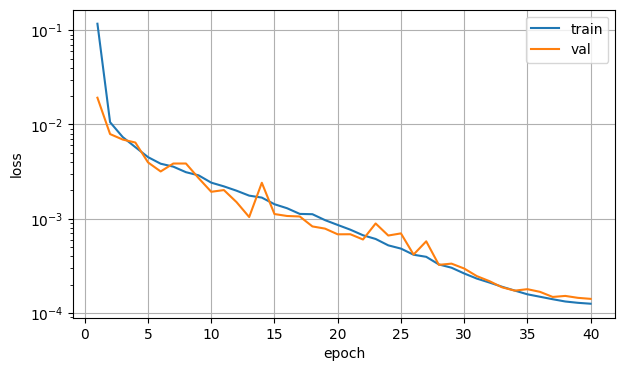

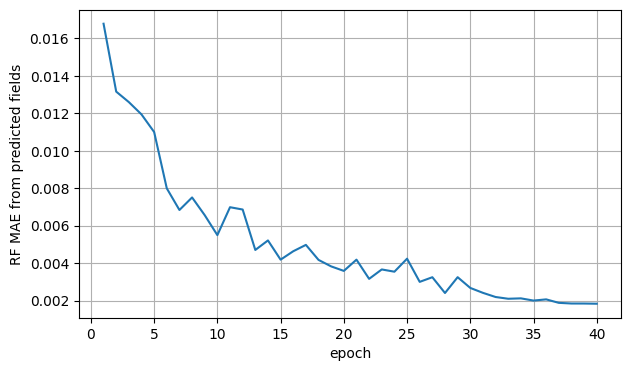

In [ ]:

plt.figure(figsize=(7,4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train")
plt.plot(hist_df["epoch"], hist_df["loss"], label="val")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist_df["epoch"], hist_df["rf_mae_from_fields"])
plt.xlabel("epoch")
plt.ylabel("RF MAE from predicted fields")
plt.grid(True)
plt.show()


In [19]:
dct = torch.load('best_model(1).pt', map_location=device, weights_only=False)
model.load_state_dict(dct['model_state_dict'])
model.eval()

UNet(
  (enc1): ConvBlock(
    (net): Sequential(
      (0): Conv2d(27, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (2): SiLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): GroupNorm(8, 32, eps=1e-05, affine=True)
      (5): SiLU()
    )
  )
  (enc2): ConvBlock(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (2): SiLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): GroupNorm(8, 64, eps=1e-05, affine=True)
      (5): SiLU()
    )
  )
  (enc3): ConvBlock(
    (net): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GroupNorm(8, 128, eps=1e-05, affine=True)
      (2): SiLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): GroupNorm(8, 12

In [21]:
!pip install SALib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 4.0 MB/s eta 0:00:00


In [24]:
train_loader

In [41]:
from SALib.sample import saltelli
from SALib.analyze import sobol

# X_data = torch.cat([xb for xb, yb in loader], dim=0)#.detach().cpu().numpy()
# features = ['x'+str(i) for i in range(X_data.shape[1])]

# problem = {
#     'num_vars': X_data.shape[1],
#     'names': features,
#     'bounds': [
#         [X_data[:, i].min(), X_data[:, i].max()]
#         for i in range(X_data.shape[1])]
# }


bounds = []

for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_min == col_max:
        eps = 1e-8 #if col_min == 0 else abs(col_min) * 1e-8
        col_min -= eps
        col_max += eps

    bounds.append([col_min, col_max])

problem = {
    "num_vars": len(feature_cols),
    "names": feature_cols,
    "bounds": bounds,
}

param_values = saltelli.sample(problem, 1024, calc_second_order=True)
X_sobol_df = pd.DataFrame(param_values, columns=feature_cols)

x_mean = torch.tensor(dct["x_scaler_mean"], dtype=torch.float32, device=device)
x_scale = torch.tensor(dct["x_scaler_scale"], dtype=torch.float32, device=device)
y_mean = torch.tensor(dct["y_scaler_mean"], dtype=torch.float32, device=device)
y_scale = torch.tensor(dct["y_scaler_scale"], dtype=torch.float32, device=device)
X_sobol = torch.tensor(
    X_sobol_df[feature_cols].values,
    dtype=torch.float32,
    device=device
)

X_sobol_scaled = (X_sobol - x_mean) / x_scale



def make_unet_input_from_tabular(xb, grid_cfg, add_xy=True):
    """
    Convert tabular input [B, n_features]
    to U-Net input [B, n_features + 2, Ny, Nx].

    The 25 scalar features become constant spatial maps.
    Two extra channels are added:
        x-grid in [0, 1]
        y-grid in [0, 1]
    """

    B, n_features = xb.shape
    device = xb.device
    dtype = xb.dtype

    if isinstance(grid_cfg, dict):
        Nx = int(grid_cfg["model_Nx"])
        Ny = int(grid_cfg["model_Ny"])
    else:
        Nx = int(grid_cfg.Nx)
        Ny = int(grid_cfg.Ny)

    # [B, n_features, Ny, Nx]
    feature_maps = xb.view(B, n_features, 1, 1).expand(B, n_features, Ny, Nx)

    if not add_xy:
        return feature_maps

    # x-coordinate map: [1, 1, Ny, Nx]
    x = torch.linspace(0.0, 1.0, Nx, device=device, dtype=dtype)
    x = x.view(1, 1, 1, Nx).expand(B, 1, Ny, Nx)

    # y-coordinate map: [1, 1, Ny, Nx]
    y = torch.linspace(0.0, 1.0, Ny, device=device, dtype=dtype)
    y = y.view(1, 1, Ny, 1).expand(B, 1, Ny, Nx)

    # Final input: [B, n_features + 2, Ny, Nx]
    xb_maps = torch.cat([feature_maps, x, y], dim=1)

    return xb_maps

param_values = saltelli.sample(problem, 1024, calc_second_order=True)
X_sobol = torch.tensor(param_values, dtype=torch.float32).to(device)
model.eval()
preds_scaled = []

batch_size = 4096

with torch.no_grad():
    for i in range(0, X_sobol_scaled.shape[0], batch_size):
        xb = X_sobol_scaled[i:i + batch_size]

        xb_maps = make_unet_input_from_tabular(
            xb,
            dct["grid_cfg"],
            add_xy=True
        )

        print("xb_maps shape:", xb_maps.shape)

        out = model(xb_maps)

        if isinstance(out, dict):
            yb_scaled = out["scalar"]
        elif isinstance(out, tuple):
            yb_scaled = out[-1]
        else:
            yb_scaled = out

        preds_scaled.append(yb_scaled.detach().cpu())

Y_pred_scaled = torch.cat(preds_scaled, dim=0).to(device)

Y_pred = Y_pred_scaled * y_scale + y_mean
Y_pred_np = Y_pred.detach().cpu().numpy()

print("Y_pred_np shape:", Y_pred_np.shape)







results = {}

for target_idx, target_name in enumerate(target_cols):
    y = Y_pred_np[:, target_idx]

    Si = sobol.analyze(
        problem,
        y,
        calc_second_order=True,
        print_to_console=False
    )

    sobol_df = pd.DataFrame({
        "feature": problem["names"],
        "S1": Si["S1"],
        "S1_conf": Si["S1_conf"],
        "ST": Si["ST"],
        "ST_conf": Si["ST_conf"],
    }).sort_values("ST", ascending=False)

    results[target_name] = {
        "Si": Si,
        "df": sobol_df,
    }

# # model.eval()
# # with torch.no_grad():
# #     Y_pred = model(X_sobol).detach().cpu().numpy()

# # Y_sw = Y_pred[:, 0]
# # Y_p = Y_pred[:, 1]

# for y_tpl in ((Y_sw, 'Y_sw'), (Y_p, 'Y_p')):
#     Si = sobol.analyze(problem, y_tpl[0], calc_second_order=True)
#     sobol_df = pd.DataFrame({
#         'feature': problem['names'],
#         'S1': Si['S1'],
#         'ST': Si['ST'],
#         'S1_conf': Si['S1_conf'],
#         'ST_conf': Si['ST_conf']})
#     sobol_df_sorted = sobol_df.sort_values('ST')
#     print(f'sobol coeffs for {y_tpl[1]}:')
#     print(sobol_df.sort_values('ST'))

#     plt.figure(figsize=(8, 5))
#     plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
#     plt.xlabel('total sobol coeff ST')
#     plt.title(f'sobol sensitivity indices for : {y_tpl[1]}')
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     print('pairwise interactions S2 for ', y_tpl[1])
#     print(pd.DataFrame(
#         Si['S2'],
#         index=problem['names'],
#         columns=problem['names']
#     ))
#     print('\n----------------------------------------\n\n\n\n')

/tmp/ipykernel_2210/3121088850.py:34: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)
/tmp/ipykernel_2210/3121088850.py:92: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024, calc_second_order=True)


xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
xb_maps shape: torch.Size([4096, 27, 32, 32])
Y_pred_np shape: (53248, 4)


sobol coeffs for final_cum_oil_prod_m3:
            feature            S1       S1_conf            ST       ST_conf
0                Lx  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
2                 h  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
1                Ly  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
9         p_ref_MPa  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
16         rho_w_sc  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
19              Sor  8.894494e-11  2.354371e-09  6.547296e-16  2.894709e-16
18              Swc -1.892100e-09  3.289443e-09  1.357667e-15  4.270441e-16
7     p_inj_bhp_MPa  1.393229e-04  7.522499e-04  8.010618e-05  2.194169e-05
14          mu_w_cP -2.418161e-04  8.408954e-04  9.657973e-05  4.292849e-05
15          mu_o_cP -1.118854e-03  8.695451e-04  1.613270e-04  7.443575e-05
12      cw_1_per_Pa -1.055038e-03  2.136361e-03  4.194151e-04  1.286455e-04
4              k_mD -2.200681e-03  1.022702e-02 

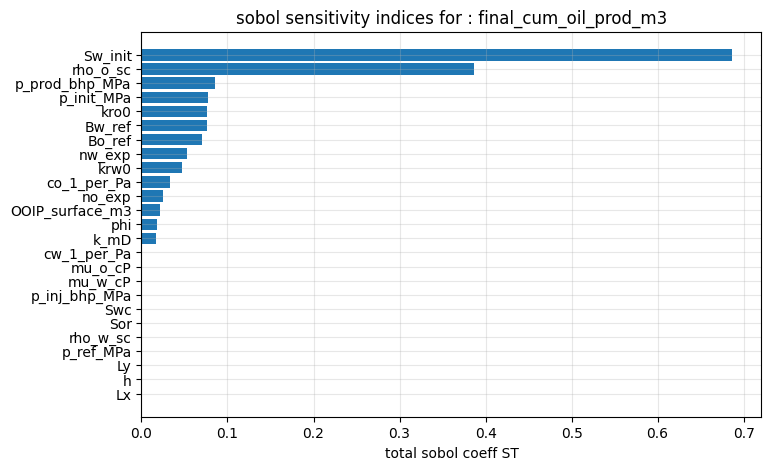

pairwise interactions S2 for  final_cum_oil_prod_m3
                 Lx            Ly             h           phi          k_mD  \
Lx              NaN -1.356619e-09 -1.356619e-09 -1.404120e-09 -1.350121e-09   
Ly              NaN           NaN -1.356619e-09 -1.404120e-09 -1.350121e-09   
h               NaN           NaN           NaN -1.404120e-09 -1.350121e-09   
phi             NaN           NaN           NaN           NaN  7.690097e-03   
k_mD            NaN           NaN           NaN           NaN           NaN   
p_init_MPa      NaN           NaN           NaN           NaN           NaN   
Sw_init         NaN           NaN           NaN           NaN           NaN   
p_inj_bhp_MPa   NaN           NaN           NaN           NaN           NaN   
p_prod_bhp_MPa  NaN           NaN           NaN           NaN           NaN   
p_ref_MPa       NaN           NaN           NaN           NaN           NaN   
Bw_ref          NaN           NaN           NaN           NaN           NaN   


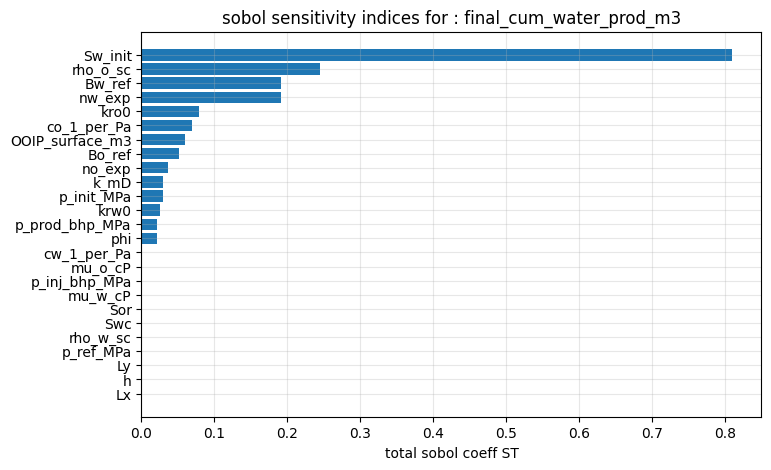

pairwise interactions S2 for  final_cum_water_prod_m3
                 Lx            Ly             h           phi          k_mD  \
Lx              NaN -2.001305e-10 -2.001305e-10 -2.001415e-10 -2.001634e-10   
Ly              NaN           NaN -2.001305e-10 -2.001415e-10 -2.001634e-10   
h               NaN           NaN           NaN -2.001415e-10 -2.001634e-10   
phi             NaN           NaN           NaN           NaN  7.839892e-03   
k_mD            NaN           NaN           NaN           NaN           NaN   
p_init_MPa      NaN           NaN           NaN           NaN           NaN   
Sw_init         NaN           NaN           NaN           NaN           NaN   
p_inj_bhp_MPa   NaN           NaN           NaN           NaN           NaN   
p_prod_bhp_MPa  NaN           NaN           NaN           NaN           NaN   
p_ref_MPa       NaN           NaN           NaN           NaN           NaN   
Bw_ref          NaN           NaN           NaN           NaN           NaN  

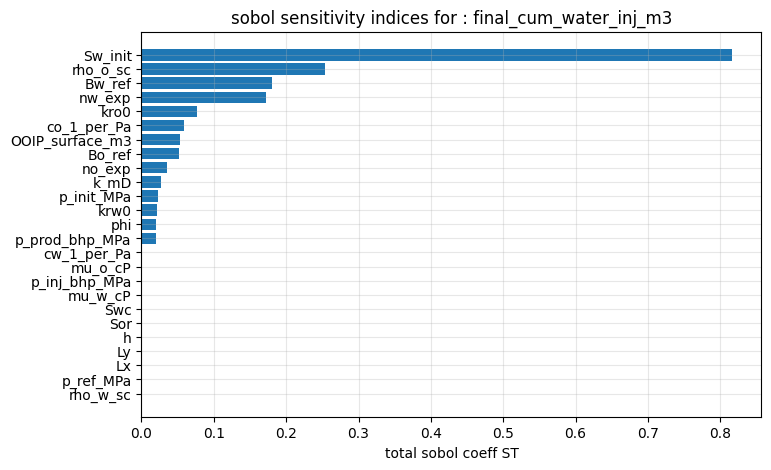

pairwise interactions S2 for  final_cum_water_inj_m3
                 Lx            Ly             h           phi          k_mD  \
Lx              NaN -2.020079e-11 -2.020079e-11 -2.020079e-11 -2.020079e-11   
Ly              NaN           NaN -1.036754e-10 -1.036754e-10 -1.036754e-10   
h               NaN           NaN           NaN -1.036754e-10 -1.036754e-10   
phi             NaN           NaN           NaN           NaN  8.580779e-03   
k_mD            NaN           NaN           NaN           NaN           NaN   
p_init_MPa      NaN           NaN           NaN           NaN           NaN   
Sw_init         NaN           NaN           NaN           NaN           NaN   
p_inj_bhp_MPa   NaN           NaN           NaN           NaN           NaN   
p_prod_bhp_MPa  NaN           NaN           NaN           NaN           NaN   
p_ref_MPa       NaN           NaN           NaN           NaN           NaN   
Bw_ref          NaN           NaN           NaN           NaN           NaN   

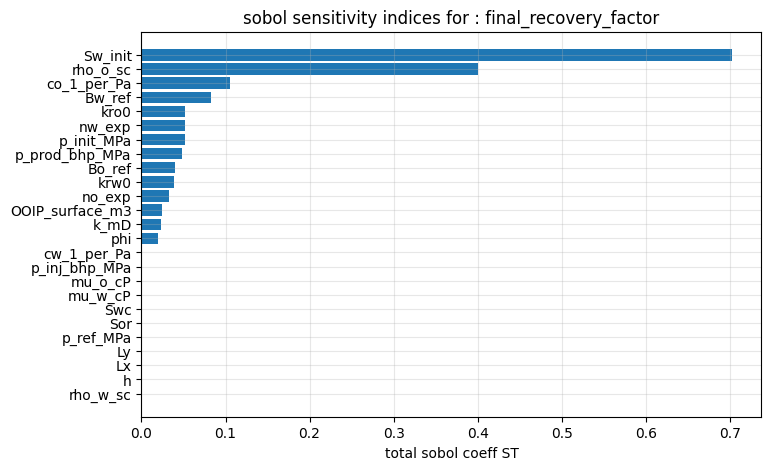

pairwise interactions S2 for  final_recovery_factor
                 Lx            Ly             h           phi          k_mD  \
Lx              NaN -5.885639e-10 -5.885639e-10 -5.877506e-10 -5.873366e-10   
Ly              NaN           NaN -5.885639e-10 -5.877506e-10 -5.873366e-10   
h               NaN           NaN           NaN -5.877506e-10 -5.873366e-10   
phi             NaN           NaN           NaN           NaN  1.516729e-02   
k_mD            NaN           NaN           NaN           NaN           NaN   
p_init_MPa      NaN           NaN           NaN           NaN           NaN   
Sw_init         NaN           NaN           NaN           NaN           NaN   
p_inj_bhp_MPa   NaN           NaN           NaN           NaN           NaN   
p_prod_bhp_MPa  NaN           NaN           NaN           NaN           NaN   
p_ref_MPa       NaN           NaN           NaN           NaN           NaN   
Bw_ref          NaN           NaN           NaN           NaN           NaN   


In [54]:
# results.keys()

for item in results.keys():
  # print(results[item].keys())
  # break

  Si = results[item]['Si']
  sobol_df = results[item]['df']
  sobol_df_sorted = sobol_df.sort_values('ST')
  print(f'sobol coeffs for {item}:')
  print(sobol_df.sort_values('ST'))

  plt.figure(figsize=(8, 5))
  plt.barh(sobol_df_sorted['feature'], sobol_df_sorted['ST'])
  plt.xlabel('total sobol coeff ST')
  plt.title(f'sobol sensitivity indices for : {item}')
  plt.grid(True, alpha=0.3)
  plt.show()

  print('pairwise interactions S2 for ', item)
  print(pd.DataFrame(
      Si['S2'],
      index=problem['names'],
      columns=problem['names']
  ))
  print('\n----------------------------------------\n\n\n\n')

In [43]:
# dct['grid_cfg']

y.shape

(53248,)